# Analisi Stress Relaxation — versione essenziale

Questo notebook è stato ridotto a **4 celle operative**:

1. **import librerie** e utility da `sr_utils.py`;
2. **impostazione input** (`data_dir` + opzioni principali);
3. **caricamento/preprocessing automatico** della curva media;
4. **analisi completa** con fit, grafici ed export in **PDF unico**.

**Uso rapido:** imposta `data_dir` nella cella 2 ed esegui le celle in ordine dall'alto verso il basso.

In [320]:
# 1. Import librerie e utility
import sys
sys.path.insert(0, r'/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo')

import importlib
import warnings
import matplotlib.pyplot as plt
import sr_utils

# Reload esplicito: evita riferimenti a versioni vecchie del modulo nel kernel.
importlib.reload(sr_utils)
resolve_sr_input = sr_utils.resolve_sr_input
load_sr_curve = sr_utils.load_sr_curve
run_sr_analysis = sr_utils.run_sr_analysis
prepare_area_means_from_day_folder = sr_utils.prepare_area_means_from_day_folder

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [321]:
# 2. Input da analizzare (versione dedicata EV/RAB5)
#
# Puoi passare direttamente:
#   - una CARTELLA con le curve SR grezze `.jpk-force`
#   - oppure un file singolo gia pronto (`*-media-norm.csv`, `.jpk-force`, ecc.)
#
# Se passi una cartella, il notebook:
#   1) genera automaticamente la curva media normalizzata
#   2) usa quella curva per i fit (in memoria)
#   3) salva solo il report finale PDF e, opzionalmente, il JPK medio

# Imposta qui la cartella giornata predefinita (usata anche come primo elemento di day_folders)
data_dir = r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/160426/0R"
input_force_mode = "auto"   # "auto" | "raw" | "normalized"
normalized_reference = "Fpicco,init"

# Batch giornate: se area_means_only=True, il notebook processa tutte le giornate elencate qui.
# Se vuoi una sola giornata, lascia solo data_dir nella lista.
day_folders = [data_dir]

# Copia centralizzata DISATTIVA per mantenere il salvataggio originale (file nelle cartelle area)
centralized_area_output_dir = r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/area_means"
copy_area_means_to_centralized_dir = False

# Se vuoi analizzare TUTTE le curve grezze della cartella: lascia None
# Se vuoi analizzare solo curve specifiche: inserisci i nomi file (con o senza estensione)
selected_curve_names = None
## Esempio:
## selected_curve_names = ["cellula_01.jpk-force", "cellula_03", "cellula_07.jpk"]

# Controllo grafico cella 2b: quante curve singole mostrare in overlay
# None (o 0) = mostra tutte le curve singole
preview_single_curves_max = 3

# Parametri usati solo se `data_dir` e' una cartella
num_curves = None            # None = usa tutte le curve trovate dopo l'eventuale filtro selected_curve_names
segment_index = None         # None = usa automaticamente il segmento pause/dwell
normalization_mode = "peak" # "peak" | "first" | "mean"
reference_points = 200       # punti iniziali usati per stimare Fpicco,init
indentation_auto_mode = "median"  # "median" | "mean_robust" | "mean"
min_curve_duration_s = 5.0   # filtra curve SR troppo brevi; utile se nella cartella ci sono acquisizioni miste (es. 0.7 s e 15 s)

# Pulizia segnali e robustezza media
spike_filter_window = 9      # filtro mediano anti-picco sottile (consigliato dispari, >=3)
spike_filter_z = 3.0         # 3-sigma anche per anti-spike
smoothing_window = 101       # None per disattivare, altrimenti finestra (consigliato dispari, >=5)
outlier_sigma = 3.0          # filtro outlier con metodo 3-sigma
min_valid_curves = 3         # minimo numero di curve concordi per tenere un punto

# Modalita elaborazione cartella giornata
area_means_only = True         # True = genera solo medie delle aree, nessuna media finale di giornata
area_save_preprocessed_mean = True
area_save_mean_csv = True

# Visualizzazione curva (solo grafico di controllo / fit panel)
plot_max_time_s = 10.0       # limita la vista del pannello fit a 10 s

# Transizione poroelastico -> viscoelastico
# transition_time_s: valore manuale di partenza (in secondi)
transition_time_s = 0.5
auto_optimize_transition = True
transition_search_range_s = (0.25, 1.20)  # intervallo di ricerca se auto=True
transition_search_steps = 41
# Criterio di accettazione: la transizione automatica viene usata solo se i due fit si raccordano bene.
transition_max_join_gap = 0.03
transition_max_local_rmse = 0.05

save_preprocessed_mean = False  # evita I/O pesante su zip .jpk-force durante il debug rapido
save_mean_csv = False           # se False la media NON viene salvata in `.csv`

# Opzioni finali di output
save_outputs = True
open_output_folder = False  # se True apre direttamente il PDF finale (fallback: cartella)

# --- Parametri geometrici per il calcolo del Modulo di Young (Hertz sferico) ---
# Imposta i valori della tua punta.
# hertz_indentation_m = None => usa automaticamente l'indentazione stimata dalla curva/media.
hertz_tip_radius_m = 5e-6      # [m] raggio punta, es. 5e-6 per 5 um
hertz_indentation_m = None     # [m] None = auto (consigliato)
hertz_poisson = 0.49           # [-] coefficiente di Poisson del campione

In [322]:
# 2b. Controllo rapido: anteprima curve selezionate
import importlib
from pathlib import Path

import sr_utils
importlib.reload(sr_utils)

if area_means_only:
    print("Modalita area_means_only attiva: la Cell 2b e disabilitata per evitare il vecchio grafico della media globale.")
    print("I risultati delle medie area vengono stampati nella Cell 3.")
else:
    print("(in questa modalita non viene mostrato il vecchio grafico globale)")



Modalita area_means_only attiva: la Cell 2b e disabilitata per evitare il vecchio grafico della media globale.
I risultati delle medie area vengono stampati nella Cell 3.


In [323]:
# 3. Workflow unificato: preparazione automatica, caricamento e preprocessing
import math
import shutil
from pathlib import Path
import pandas as pd

if area_means_only:
    day_list = [str(Path(p)) for p in day_folders if str(p).strip()] if 'day_folders' in globals() else [data_dir]
    if not day_list:
        raise ValueError("Nessuna cartella giornata valida in day_folders")

    area_means_all_days = {}
    summary_frames = []

    print(f"Batch area_means_only: {len(day_list)} giornata/e da processare")
    for day_path in day_list:
        print("\n" + "=" * 90)
        print(f"Giornata: {day_path}")
        pack = prepare_area_means_from_day_folder(
            day_path,
            num_curves=num_curves,
            selected_curve_names=selected_curve_names,
            segment_index=segment_index,
            normalization_mode=normalization_mode,
            reference_points=reference_points,
            outlier_sigma=outlier_sigma,
            min_valid_curves=min_valid_curves,
            smoothing_window=smoothing_window,
            spike_filter_window=spike_filter_window,
            spike_filter_z=spike_filter_z,
            min_curve_duration_s=min_curve_duration_s,
            indentation_auto_mode=indentation_auto_mode,
            save_preprocessed_mean=area_save_preprocessed_mean,
            save_mean_csv=area_save_mean_csv,
        )
        area_means_all_days[day_path] = pack

        df_day = pack.get("area_summary_df")
        if df_day is not None and len(df_day) > 0:
            df_day = df_day.copy()
            day_name = Path(day_path).name
            df_day.insert(0, "giornata", day_name)
            summary_frames.append(df_day)

            # File assieme per singola giornata (salvato nella cartella della giornata).
            day_summary_csv = Path(day_path) / f"{day_name}_area_results_summary.csv"
            df_day.to_csv(day_summary_csv, index=False)
            print(f"Riepilogo area salvato per giornata: {day_summary_csv}")

    area_means_pack = area_means_all_days
    analysis_input_path = None
    sr = None

    if summary_frames:
        area_means_global_summary_df = pd.concat(summary_frames, ignore_index=True)
        print("\n" + "=" * 90)
        print("Riepilogo globale medie area generate (tutte le giornate):")
        display(area_means_global_summary_df)
        print(f"Totale medie area generate: {len(area_means_global_summary_df)}")

        # File assieme globale salvato nella cartella giornata predefinita (data_dir).
        default_day_dir = Path(data_dir)
        default_day_dir.mkdir(parents=True, exist_ok=True)
        global_summary_csv = default_day_dir / "all_days_area_results_summary.csv"
        area_means_global_summary_df.to_csv(global_summary_csv, index=False)
        print(f"Riepilogo globale area salvato in: {global_summary_csv}")
    else:
        area_means_global_summary_df = pd.DataFrame()
        print("Nessuna media area generata nel batch")

    if copy_area_means_to_centralized_dir and not area_means_global_summary_df.empty:
        central_root = Path(centralized_area_output_dir)
        central_root.mkdir(parents=True, exist_ok=True)
        copied_rows = []

        for day_path, day_pack in area_means_pack.items():
            day_name = Path(day_path).name
            for item in day_pack.get("area_results", []):
                area_name = str(item.get("area_name", "area_unknown"))
                area_target_dir = central_root / day_name / area_name
                area_target_dir.mkdir(parents=True, exist_ok=True)

                for key in ["jpk_path", "csv_path"]:
                    src = item.get(key)
                    if not src:
                        continue
                    src_path = Path(src)
                    if not src_path.exists():
                        continue
                    dst_path = area_target_dir / src_path.name
                    shutil.copy2(src_path, dst_path)
                    copied_rows.append(
                        {
                            "giornata": day_name,
                            "area": area_name,
                            "tipo": "JPK" if key == "jpk_path" else "CSV",
                            "source": str(src_path),
                            "destinazione": str(dst_path),
                        }
                    )

        copied_df = pd.DataFrame(copied_rows)
        print("\n" + "=" * 90)
        print(f"Copia centralizzata completata in: {central_root}")
        if not copied_df.empty:
            display(copied_df)
            print(f"File copiati: {len(copied_df)}")
        else:
            print("Nessun file copiato (controlla area_save_preprocessed_mean / area_save_mean_csv)")

    if not copy_area_means_to_centralized_dir:
        print("Salvataggio originale attivo: i file restano nelle rispettive cartelle area.")

    print("Modalita area_means_only attiva: medie area generate e stampate. Nessuna media finale di giornata.")
else:
    analysis_input_path = resolve_sr_input(
        data_dir,
        num_curves=num_curves,
        selected_curve_names=selected_curve_names,
        segment_index=segment_index,
        normalization_mode=normalization_mode,
        reference_points=reference_points,
        outlier_sigma=outlier_sigma,
        min_valid_curves=min_valid_curves,
        smoothing_window=smoothing_window,
        spike_filter_window=spike_filter_window,
        spike_filter_z=spike_filter_z,
        min_curve_duration_s=min_curve_duration_s,
        indentation_auto_mode=indentation_auto_mode,
        save_preprocessed_mean=save_preprocessed_mean,
        save_mean_csv=save_mean_csv,
     )

    print(f"Input selezionato: {data_dir}")
    if isinstance(analysis_input_path, dict):
        print(f"Input effettivo per l'analisi: {analysis_input_path['display_name']}")
    else:
        print(f"Input effettivo per l'analisi: {analysis_input_path}")
    print(f"Modalita auto-indentazione: {indentation_auto_mode}")

    sr = load_sr_curve(
        analysis_input_path,
        input_force_mode=input_force_mode,
        normalized_reference=normalized_reference,
     )

    print(f"Segmento dwell: {len(sr['t_pause'])} punti  |  durata = {sr['t_pause'][-1]:.2f} s")
    print(f"Forza iniziale dwell: {sr['force_pause'][0] * sr['force_scale']:.3f} {sr['force_unit']}")
    print(f"Forza finale dwell:   {sr['force_pause'][-1] * sr['force_scale']:.3f} {sr['force_unit']}")

    indent_est = sr.get('estimated_indentation_m', float('nan'))
    if isinstance(indent_est, (int, float)) and math.isfinite(indent_est):
        print(f"Indentazione stimata (auto): {indent_est * 1e9:.3f} nm")
    else:
        print("Indentazione stimata (auto): n/d")

Batch area_means_only: 1 giornata/e da processare

Giornata: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/160426/0R
Modalita area-only: calcolo medie separate per ogni area (nessuna media finale di giornata)
- Giornata: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/160426/0R
- Aree candidate: 9

=== Area: cell01 ===
Cartella rilevata → genero automaticamente la curva media normalizzata
- Cartella dati: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/160426/0R/cell01
- Selezione curve: tutte le curve grezze disponibili
- Curve candidate: 5
  • cell1_SR-0000.jpk-force
  • cell1_SR-0001.jpk-force
  • cell1_SR-0002.jpk-force
  • cell1_SR-0003.jpk-force
  • cell1_substrate.jpk-force
- Curve escluse per errore di lettura: 1
  ! cell1_substrate.jpk-force: durata troppo breve (1.133 s < 5.000 s)
- Curve valide usate per la media: 4
- Intervallo comune usato: 0.0000 s - 14.9999 s
- Punti temporali mantenuti: 150000
- Spike sottili corretti (mediana robusta): 11326
- Valor

,area,folder,n_points,jpk_path,csv_path
0,cell01,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
1,cell02,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
2,cell03,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,111629,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
3,cell04,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
4,cell05,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
5,cell06,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
6,cell07,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
7,cell08,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
8,cell09,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,83564,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...


Riepilogo area salvato per giornata: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/160426/0R/0R_area_results_summary.csv

Riepilogo globale medie area generate (tutte le giornate):


,giornata,area,folder,n_points,jpk_path,csv_path
0,0R,cell01,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
1,0R,cell02,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
2,0R,cell03,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,111629,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
3,0R,cell04,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
4,0R,cell05,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
5,0R,cell06,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
6,0R,cell07,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
7,0R,cell08,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,150000,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...
8,0R,cell09,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,83564,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...,/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI...


Totale medie area generate: 9
Riepilogo globale area salvato in: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/160426/0R/all_days_area_results_summary.csv
Salvataggio originale attivo: i file restano nelle rispettive cartelle area.
Modalita area_means_only attiva: medie area generate e stampate. Nessuna media finale di giornata.


In [324]:
# 4. Analisi finale: fit, grafici ed export tramite modulo esterno
import importlib
import sr_utils

importlib.reload(sr_utils)

if area_means_only:
    print("Modalita area_means_only attiva: salto il fit finale su media di giornata.")
    print("Usa i file medi per area generati nella cella 3 nel notebook Media delle Medie.")
    analysis_results = {}
else:
    analysis_results = sr_utils.run_sr_analysis(
        sr=sr,
        analysis_input_path=analysis_input_path,
        save_outputs=save_outputs,
        open_output_folder=open_output_folder,
        plot_max_time_s=plot_max_time_s,
        fit_spike_filter_window=spike_filter_window,
        fit_spike_filter_z=spike_filter_z,
        fit_smoothing_window=smoothing_window,
        transition_time_s=transition_time_s,
        auto_optimize_transition=auto_optimize_transition,
        transition_search_range_s=transition_search_range_s,
        transition_search_steps=transition_search_steps,
        transition_max_join_gap=transition_max_join_gap,
        transition_max_local_rmse=transition_max_local_rmse,
        hertz_tip_radius_m=hertz_tip_radius_m,
        hertz_indentation_m=hertz_indentation_m,
        hertz_poisson=hertz_poisson,
    )

    # Rende disponibili nel notebook i risultati principali per eventuali controlli manuali
    globals().update(analysis_results)

    print(f"Transizione poro/visco selezionata: {analysis_results.get('transition_time_selected_s', float('nan')):.3f} s")

Modalita area_means_only attiva: salto il fit finale su media di giornata.
Usa i file medi per area generati nella cella 3 nel notebook Media delle Medie.


In [325]:
# 5. Diagnostica Young/PLR (essenziale)
import numpy as np

diag = analysis_results.get("young_diagnostics", {})
print("young_message:", analysis_results.get("young_message"))
print("--- Diagnostica Young ---")
for key in [
    "is_normalized_input",
    "f_peak_mean_N",
    "F0_from_plr_N",
    "F0_from_norm_only_N",
    "tip_radius_m",
    "indentation_m",
    "nu",
    "geom_term",
    "young_prefactor",
    "young_pa",
    "young_if_delta_half_pa",
    "young_if_delta_double_pa",
]:
    value = diag.get(key)
    if key in {"indentation_m", "estimated_indentation_m", "indentation_used_for_young_m"} and value is not None and np.isfinite(value):
        print(f"{key}: {value * 1e9:.3f} nm")
    else:
        print(f"{key}: {value}")


young_message: None
--- Diagnostica Young ---
is_normalized_input: None
f_peak_mean_N: None
F0_from_plr_N: None
F0_from_norm_only_N: None
tip_radius_m: None
indentation_m: None
nu: None
geom_term: None
young_prefactor: None
young_pa: None
young_if_delta_half_pa: None
young_if_delta_double_pa: None


=== Young EV vs RAB5 ===


,Gruppo,N_cellule,Young_media_Pa,Young_SD_Pa,Young_media_kPa,Young_SD_kPa
0,EV,4,326.209481,125.794553,0.326209,0.125795
1,RAB5,4,198.125996,264.724776,0.198126,0.264725



=== Tempo transizione poro -> visco (stima automatica) ===


,Gruppo,N_cellule,Ttrans_media_s,Ttrans_mediana_s,Ttrans_SD_s,Delta_vs_richiesta_media_s,Fallback_n
0,EV,1,0.29750,0.29750,NaN,-0.20250,0
1,RAB5,1,0.27375,0.27375,NaN,-0.22625,0



Controllo rispetto a 0.5 s:
  EV   : mediana = 0.297 s | scarto da 0.5 = -0.203 s | N=1
  RAB5 : mediana = 0.274 s | scarto da 0.5 = -0.226 s | N=1
Confronto statistico EV vs RAB5 non eseguito (servono >=2 valori per gruppo e scipy.stats).


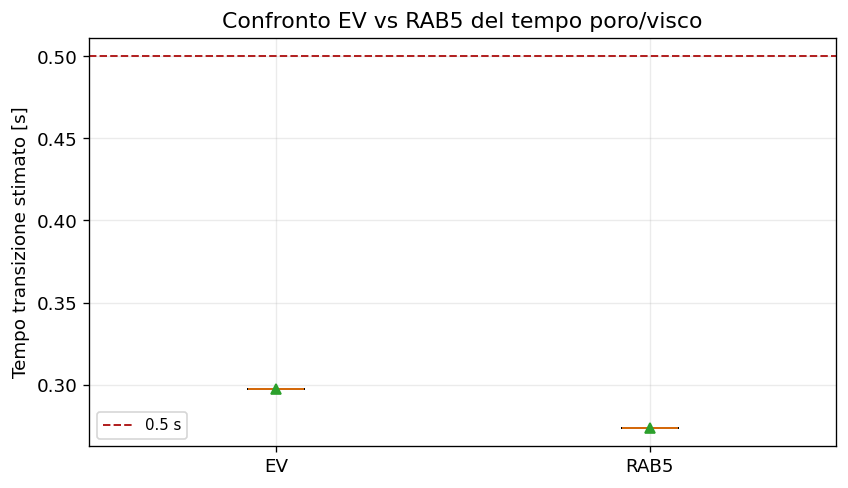


Riepilogo transizione salvato in: /Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo/aggregated/Riassunto/SR/transition_summary_EV_RAB5.csv


In [326]:
# 6. Confronto EV vs RAB5: Young + tempo transizione poro/visco
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import mannwhitneyu
except Exception:
    mannwhitneyu = None

summary_root = Path(r"/Users/furbetta/Desktop/PyFMlab_DyNaMo/PyFMGUI_DyNaMo")
summary_files = sorted(summary_root.glob("**/*_young_summary.json"))

if not summary_files:
    raise FileNotFoundError(
        f"Nessun file *_young_summary.json trovato sotto {summary_root}. "
        "Esegui prima l'analisi delle singole cellule per generare i riepiloghi."
    )

rows = []
for path in summary_files:
    data = json.loads(path.read_text())
    haystack = f"{data.get('data_dir', '')} {data.get('analysis_label', '')} {path}".upper()
    if re.search(r"(^|[\\/_-])EV([\\/_-]|$)", haystack):
        group = "EV"
    elif re.search(r"(^|[\\/_-])RAB5([\\/_-]|$)", haystack):
        group = "RAB5"
    else:
        continue

    rows.append({
        "Gruppo": group,
        "Young_Pa": float(data["young_modulus_pa"]) if data.get("young_modulus_pa") is not None else np.nan,
        "Young_kPa": float(data["young_modulus_kpa"]) if data.get("young_modulus_kpa") is not None else np.nan,
        "Transition_s": float(data["transition_time_selected_s"]) if data.get("transition_time_selected_s") is not None else np.nan,
        "Transition_req_s": float(data["transition_time_requested_s"]) if data.get("transition_time_requested_s") is not None else np.nan,
        "Transition_delta_s": float(data["transition_delta_vs_requested_s"]) if data.get("transition_delta_vs_requested_s") is not None else np.nan,
        "Transition_fallback": bool(data.get("transition_used_fallback", False)),
        "Transition_reason": data.get("transition_selection_reason", "n/d"),
        "Transition_best_score": float(data["transition_best_score"]) if data.get("transition_best_score") is not None else np.nan,
        "file": str(path),
    })

if not rows:
    raise ValueError("Nessun riepilogo EV/RAB5 trovato.")

df = pd.DataFrame(rows)

# --- 1) Riepilogo Young ---
young_df = df[np.isfinite(df["Young_Pa"])].copy()
if len(young_df) > 0:
    young_summary_df = (
        young_df.groupby("Gruppo", as_index=False)
        .agg(
            N_cellule=("Young_Pa", "count"),
            Young_media_Pa=("Young_Pa", "mean"),
            Young_SD_Pa=("Young_Pa", "std"),
            Young_media_kPa=("Young_kPa", "mean"),
            Young_SD_kPa=("Young_kPa", "std"),
        )
        .sort_values(by="Gruppo")
        .reset_index(drop=True)
    )
    print("=== Young EV vs RAB5 ===")
    display(young_summary_df)
else:
    print("Nessun valore Young valido trovato nei riepiloghi.")

# --- 2) Riepilogo tempo transizione poro/visco ---
tr_df = df[np.isfinite(df["Transition_s"])].copy()
if len(tr_df) == 0:
    print(
        "Nessun tempo di transizione disponibile nei riepiloghi attuali. "
        "Per popolare questi campi, riesegui la Cell 4 in modalita non area_means_only "
        "sui file/giornate EV e RAB5 di interesse."
    )
else:
    transition_summary_df = (
        tr_df.groupby("Gruppo", as_index=False)
        .agg(
            N_cellule=("Transition_s", "count"),
            Ttrans_media_s=("Transition_s", "mean"),
            Ttrans_mediana_s=("Transition_s", "median"),
            Ttrans_SD_s=("Transition_s", "std"),
            Delta_vs_richiesta_media_s=("Transition_delta_s", "mean"),
            Fallback_n=("Transition_fallback", "sum"),
        )
        .sort_values(by="Gruppo")
        .reset_index(drop=True)
    )

    print("\n=== Tempo transizione poro -> visco (stima automatica) ===")
    display(transition_summary_df)

    ev_t = tr_df.loc[tr_df["Gruppo"] == "EV", "Transition_s"].dropna().to_numpy(dtype=float)
    rab5_t = tr_df.loc[tr_df["Gruppo"] == "RAB5", "Transition_s"].dropna().to_numpy(dtype=float)

    print("\nControllo rispetto a 0.5 s:")
    if len(ev_t):
        print(f"  EV   : mediana = {np.nanmedian(ev_t):.3f} s | scarto da 0.5 = {np.nanmedian(ev_t)-0.5:+.3f} s | N={len(ev_t)}")
    else:
        print("  EV   : dati insufficienti")
    if len(rab5_t):
        print(f"  RAB5 : mediana = {np.nanmedian(rab5_t):.3f} s | scarto da 0.5 = {np.nanmedian(rab5_t)-0.5:+.3f} s | N={len(rab5_t)}")
    else:
        print("  RAB5 : dati insufficienti")

    if len(ev_t) >= 2 and len(rab5_t) >= 2 and mannwhitneyu is not None:
        stat, p_val = mannwhitneyu(ev_t, rab5_t, alternative="two-sided")
        print(f"Confronto EV vs RAB5 (Mann-Whitney): U={stat:.3f}, p-value={p_val:.5f}")
    else:
        print("Confronto statistico EV vs RAB5 non eseguito (servono >=2 valori per gruppo e scipy.stats).")

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    plot_groups = [g for g in ["EV", "RAB5"] if g in tr_df["Gruppo"].unique()]
    plot_data = [tr_df.loc[tr_df["Gruppo"] == g, "Transition_s"].dropna().to_numpy(dtype=float) for g in plot_groups]
    if any(len(x) > 0 for x in plot_data):
        ax.boxplot(plot_data, tick_labels=plot_groups, showmeans=True)
        ax.axhline(0.5, color="firebrick", ls="--", lw=1.2, label="0.5 s")
        ax.set_ylabel("Tempo transizione stimato [s]")
        ax.set_title("Confronto EV vs RAB5 del tempo poro/visco")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=9)
        plt.tight_layout()
        plt.show()

    transition_export = summary_root / "aggregated" / "Riassunto" / "SR" / "transition_summary_EV_RAB5.csv"
    transition_export.parent.mkdir(parents=True, exist_ok=True)
    transition_summary_df.to_csv(transition_export, index=False)
    print(f"\nRiepilogo transizione salvato in: {transition_export}")